# Joint glitch + galactic binary inference — TDI 1 vs TDI 2

One-year LISA observation in the mHz band containing:
- A monochromatic **galactic binary** (GB) at f₀ = 2 mHz — narrow spectral line.
- A **single-exponential glitch** at t0 = 400 s with τ = 300 s — broadband, with its spectral knee
  1/(2πτ) ≈ 0.5 mHz **inside** the analysis band, so τ (and through it t0) is measurable.
  With a short glitch (τ ≪ 1 s as in `lisa.ipynb`, knee at ~0.2 Hz) only the combinations
  A_g = Δv·τ and t0+2τ are constrained below 3 mHz: the in-band FT is ≈ A_g·e^{−2πif(t0+2τ)}/(2πf)·TF(f),
  and the τ/t0 posteriors degenerate into a prior-dominated banana.

## Hybrid frequency-domain likelihood
The GB is spectrally well-resolved (power concentrated in N_GB = 256 fine bins).  
The glitch is broadband (smooth, slowly varying spectrum across the full band).

**Strategy**: split the likelihood into two complementary sums:
1. **Binned coarse grid** (outside the GB window) — glitch model only.  
   The fine bins are grouped into ~1700 narrow blocks; each block keeps the
   inverse-variance sufficient statistics `W = Σ 1/S`, `D = Σ d/S`, `X = Σ |d|²/S`
   of **all** its fine bins, so no data are discarded:  
   `Σ_k |d_k − h_k|²/S_k = X − 2Re[h(f̄)*D] + |h(f̄)|²W` (exact for h smooth in the block).  
   Naive decimation ("keep every K-th bin, weight by K") preserves the Fisher
   information but amplifies the noise-induced posterior shift by √K — the
   posterior then lands ~√K σ away from the truth. Binning keeps both the
   information **and** the noise statistics of the full grid.
2. **Fine GB window** (N_WIN bins centred on f₀, fixed) — glitch + GB model,
   with the analytic glitch FT evaluated at the fine window frequencies.

The GB signal is placed inside the window with `jax.lax.dynamic_update_slice` so that  
f₀ can vary freely during sampling.

**TDI-1 / TDI-2 consistency** (same physics as `lisa.ipynb`):  
`h_TDI2 = −TFX1 · h_TDI1`, `n_TDI2 = −TFX1 · n_TDI1`, `S_TDI2 = |TFX1|² · S_TDI1`  
⟹ log L₂(θ) ≡ log L₁(θ) up to binning residuals ≲ 0.1. Both chains sample the same posterior.

**Inferred parameters** (7 total):  
`[log f₀, log ḟ, log A_GB, ψ_GB,   t0, log(Δv·τ), log τ]`  
Fixed: ra, dec, ι, φ₀.  ḟ = 10⁻¹⁷ Hz/s (heavy chirp mass) makes the chirp resolvable
in one year, so **all 7 posteriors are data-constrained**.

> **Kernel**: use the `jaxgb` conda environment (`miniconda3/envs/jaxgb`).

In [1]:
import sys, os, time
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

import jax
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

import lisaorbits
from jaxgb import jaxgb as jgb_mod

import jaxglitches as jg
from jaxglitches.waveform import tdi1_1exp_f_glitch, tdi2_1exp_f_glitch, AET
from jaxglitches.priors import _DELTAV_MIN, _DELTAV_MAX, _TAU_MIN, _TAU_MAX
import noise as ns

from jexplore.sampler import JaxSampler, Steps
from jexplore.sampling import EpochMH, SamplingMH
from jexplore.steps import Stretch
from jexplore.backends import DefaultBackend

print('JAX devices:', jax.devices())

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


JAX devices: [CpuDevice(id=0)]


## 1. Setup: observation, frequency grid, noise PSDs

In [2]:
YEAR_s         = 364 * 24 * 3600          # 1-year observation
SAMPLING_STEP_s = 1.0 / (2.0 * 3e-3)     # Nyquist for 3 mHz LISA band (~167 s)
T_ARM          = jg.T_ARM_s               # one-way light travel time ~8.336 s

n_samples = int(YEAR_s / SAMPLING_STEP_s)
YEAR_s    = n_samples * SAMPLING_STEP_s   # adjust to integer multiple

freq_fine  = jnp.fft.rfftfreq(n_samples, SAMPLING_STEP_s)   # (n_fine,)
n_fine     = len(freq_fine)
f_safe     = jnp.where(freq_fine > 0, freq_fine, 1.0)
df         = float(freq_fine[1])

psd1_fine  = ns.psd_tdi1_array(f_safe)   # (n_fine, 3)  TDI-1 [A, E, T]
psd2_fine  = ns.psd_tdi2_array(f_safe)   # (n_fine, 3)  TDI-2

# TDI-1 -> TDI-2 transfer function: h_TDI2 = -TFX1 * h_TDI1
TFX1 = -1.0 + jnp.exp(-4j * T_ARM * 2.0 * jnp.pi * f_safe)  # (n_fine,)

print(f'n_fine = {n_fine},  df = {df:.3e} Hz,  fmax = {float(freq_fine[-1]):.4f} Hz')

n_fine = 94349,  df = 3.180e-08 Hz,  fmax = 0.0030 Hz


## 2. True parameters, signal generation, SNR

In [3]:
# ── Galactic binary true parameters ──────────────────────────────────────────
F0_TRUE   = 2.0e-3    # Hz   (2 mHz)
FDOT_TRUE = 1.0e-17   # Hz/s (heavy chirp mass — resolvable over 1 yr: σ_fdot ≈ 1e-18)
A_GB_TRUE = 1.0e-22   # dimensionless strain amplitude  (10× louder for better constraints)
PSI_TRUE  = jnp.pi / 4

# Fixed GB parameters (not inferred)
RA_TRUE, DEC_TRUE, IOTA_TRUE, PHI0_TRUE = 1.0, -0.5, 1.0, 0.0

gb_params_true = jnp.array([[F0_TRUE, FDOT_TRUE, A_GB_TRUE,
                               RA_TRUE, DEC_TRUE, PSI_TRUE, IOTA_TRUE, PHI0_TRUE]])

# ── Single-exponential glitch true parameters ──────────────────────────────────────────
# τ sets the spectral knee f_knee = 1/(2πτ).  The knee must sit IN BAND for τ
# (and through it t0) to be measurable: here the band stops at 3 mHz, so τ must
# be O(100 s).  With a short glitch (knee out of band, as in lisa.ipynb at τ≈0.8 s)
# log τ is prior-dominated and t0 is dragged along a degeneracy line.
#
# AMPLITUDE CONVENTION: for the 1-exp model the signal ∝ Δv, so DELTAV_TRUE is the
# physical velocity kick.  (The old shapelet template used the amplitude A₀ with
# signal ∝ 2·A₀·τ; the equivalent physical kick is Δv = 2·A₀·τ.  Reusing the old
# shapelet value here would shrink the glitch by a factor 2τ ≈ 600 → SNR ≈ 0.8 and
# t0/τ/A_g would be unconstrained.)
T0_TRUE    = 400.0         # s
TAU_TRUE   = 300.0         # s   → knee at 1/(2πτ) ≈ 5.3e-4 Hz (in band)
DELTAV_TRUE = 2.9e-12       # m/s (physical velocity kick) → glitch SNR ≈ 500
A_G_TRUE    = DELTAV_TRUE * TAU_TRUE   # ≈ 8.7e-10

glitch_params_true = jnp.array([T0_TRUE, DELTAV_TRUE, TAU_TRUE])

# ── jaxgb model ───────────────────────────────────────────────────────────────
N_GB    = 256
orbit   = lisaorbits.EqualArmlengthOrbits()
jgb_model = jgb_mod.JaxGB(orbit, t_obs=float(YEAR_s), t0=0.0, n=N_GB)

k_min_true = int(jgb_model.get_kmin(gb_params_true[:, 0])[0])
print(f'k_min_true = {k_min_true},  freq[k_min] = {float(freq_fine[k_min_true]):.4e} Hz')

# ── GB signal (TDI-1.5 ≈ TDI-1) ──────────────────────────────────────────────
segs_true   = jgb_model.get_tdi(gb_params_true, tdi_generation=1.5, tdi_combination='AET')
segs_stacked = jnp.stack(segs_true, axis=0).astype(jnp.complex128)  # (3, 1, N_GB)
h_gb_win_true = segs_stacked[:, 0, :].T   # (N_GB, 3)

h_gb_tdi1 = jnp.zeros((n_fine, 3), dtype=jnp.complex128)
h_gb_tdi1 = h_gb_tdi1.at[k_min_true + jnp.arange(N_GB)].set(h_gb_win_true)

# ── Glitch signal (TDI-1) ─────────────────────────────────────────────────────
X, Y, Z = tdi1_1exp_f_glitch(f_safe, T0_TRUE, DELTAV_TRUE, TAU_TRUE, T_ARM)
A_ch, E_ch, T_ch = AET(X, Y, Z)
h_glitch_tdi1 = jnp.stack([A_ch, E_ch, T_ch], axis=-1).at[0].set(0+0j)  # (n_fine, 3)

# ── TDI-2 via -TFX1 transformation ───────────────────────────────────────────
h_gb_tdi2     = (-TFX1[:, None] * h_gb_tdi1    ).at[0].set(0+0j)
h_glitch_tdi2 = (-TFX1[:, None] * h_glitch_tdi1).at[0].set(0+0j)

# ── SNR check ────────────────────────────────────────────────────────────────
snr_gb1 = float(jg.snr(h_gb_tdi1, psd1_fine))
snr_gb2 = float(jg.snr(h_gb_tdi2, psd2_fine))
snr_g1  = float(jg.snr(h_glitch_tdi1, psd1_fine))
snr_g2  = float(jg.snr(h_glitch_tdi2, psd2_fine))
print(f'GB     SNR  TDI-1: {snr_gb1:.1f}   TDI-2: {snr_gb2:.1f}   ratio: {snr_gb2/snr_gb1:.6f}')
print(f'Glitch SNR  TDI-1: {snr_g1:.1f}   TDI-2: {snr_g2:.1f}   ratio: {snr_g2/snr_g1:.6f}')

k_min_true = 62771,  freq[k_min] = 1.9959e-03 Hz
GB     SNR  TDI-1: 4955.3   TDI-2: 4955.3   ratio: 1.000000
Glitch SNR  TDI-1: 500.1   TDI-2: 500.1   ratio: 1.000000


In [4]:
# ── Noise + data ─────────────────────────────────────────────────────────────
key = jr.PRNGKey(0)
kn, _ = jr.split(key)
n_fd_tdi1 = ns.sample_noise_fd(kn, psd1_fine)
# TDI-2 noise derived from TDI-1 (same physical realisation, per lisa.ipynb)
n_fd_tdi2 = (-TFX1[:, None] * n_fd_tdi1).at[0].set(0+0j)

data_tdi1 = h_gb_tdi1 + h_glitch_tdi1 + n_fd_tdi1
data_tdi2 = h_gb_tdi2 + h_glitch_tdi2 + n_fd_tdi2

ip1 = float(jg.inner_product(data_tdi1, h_gb_tdi1+h_glitch_tdi1, psd1_fine))
ip2 = float(jg.inner_product(data_tdi2, h_gb_tdi2+h_glitch_tdi2, psd2_fine))
snr_tot = float(jg.snr(h_gb_tdi1+h_glitch_tdi1, psd1_fine))
print(f'(d|h)/SNR²  TDI-1: {ip1/snr_tot**2:.4f}  TDI-2: {ip2/snr_tot**2:.4f}  (exp ≈ 1)')

(d|h)/SNR²  TDI-1: 0.9997  TDI-2: 0.9997  (exp ≈ 1)


## 3. Hybrid frequency grid: inverse-variance binned coarse grid + fine GB window

- **Binned coarse grid**: the fine bins outside the GB window are grouped into blocks of width
  `Δf = clip(0.005·f, df, 5 µHz)` — single fine bins at the lowest frequencies, 0.5%-wide
  logarithmic blocks through the middle of the band, 5 µHz linear blocks at the top.
- **Fine GB window**: `N_WIN = N_GB + 2·BUF` bins centred on `k_min_true` (fixed).

Per block `b` (and per channel) we precompute the sufficient statistics
`W_b = Σ_k 1/S_k`, `D_b = Σ_k d_k/S_k`, `X_b = Σ_k |d_k|²/S_k` and the weighted mean
frequency `f̄_b`. For a model that is smooth across the block,

`Σ_k |d_k − h(f_k)|²/S_k  =  X_b − 2·Re[h(f̄_b)* D_b] + |h(f̄_b)|² W_b`

so **all** fine bins enter the likelihood at the cost of one model evaluation per block.
Block widths are chosen so the glitch model is indeed smooth within each block:
the phase `2πf(t0+2τ)` varies by < 0.05 rad and `|h|` by < 1% across any block.

The glitch contribution in the window is computed at the fixed fine window frequencies.  
The GB signal is placed dynamically (varies with sampled f₀) via `jax.lax.dynamic_update_slice`.

In [5]:
BUF = 64     # extra bins on each side of the GB window

K_WIN_LO = max(1, k_min_true - BUF)
N_WIN    = N_GB + 2 * BUF          # = 384
K_WIN_HI = K_WIN_LO + N_WIN

# Fixed window arrays (precomputed, not recomputed per likelihood call)
freq_win_jnp  = jnp.array(freq_fine[K_WIN_LO:K_WIN_HI])          # (N_WIN,)
data_win1     = jnp.array(data_tdi1[K_WIN_LO:K_WIN_HI])          # (N_WIN, 3)
data_win2     = jnp.array(data_tdi2[K_WIN_LO:K_WIN_HI])
psd_win1      = jnp.array(psd1_fine[K_WIN_LO:K_WIN_HI])
psd_win2      = jnp.array(psd2_fine[K_WIN_LO:K_WIN_HI])

# ── Binned coarse grid ────────────────────────────────────────────────────────
# Block width = clip(RELW·f, df, DF_MAX): single fine bins at low f (no binning),
# 0.5%-wide log blocks in the middle, DF_MAX-wide linear blocks at the top.
# DF_MAX keeps the glitch phase variation 2π·Δf·(t0+2τ) < 0.05 rad per block.
RELW, DF_MAX_HZ = 0.005, 5e-6
W_MAX_BINS = max(1, int(round(DF_MAX_HZ / df)))

_starts, k = [], 1                  # start at k=1: DC bin excluded
while k < n_fine:
    _starts.append(k)
    k += min(max(int(RELW * k), 1), W_MAX_BINS)
block_starts = jnp.array(_starts)
N_BLOCKS_FULL = len(_starts)

# Block index of every fine bin (DC bin k=0 mapped past the last block -> dropped).
_seg = jnp.searchsorted(block_starts, jnp.arange(n_fine), side='right') - 1
_seg = jnp.where(_seg < 0, N_BLOCKS_FULL, _seg)

def block_sums(data, psd):
    """Per-block inverse-variance sufficient statistics, excluding window bins.

    Returns (W, D, X, fbar): W = Σ 1/S, D = Σ d/S, X = Σ |d|²/S, each (N_BLOCKS, 3),
    plus the weight-averaged block frequency fbar (N_BLOCKS,). All fine bins are kept
    (jax.ops.segment_sum is the exact equivalent of np.add.reduceat); blocks that fall
    entirely inside the GB window are dropped."""
    kk     = jnp.arange(n_fine)
    in_win = (kk >= K_WIN_LO) & (kk < K_WIN_HI)
    inv_S  = jnp.where(in_win[:, None], 0.0, 1.0 / psd)            # window bins removed
    seg_sum = lambda v: jax.ops.segment_sum(v, _seg, num_segments=N_BLOCKS_FULL)
    W    = seg_sum(inv_S)                                           # (N_BLOCKS_FULL, 3)
    D    = seg_sum(data * inv_S)
    X    = seg_sum(jnp.abs(data)**2 * inv_S)
    wf   = jnp.sum(inv_S, axis=1)                                   # frequency weight
    wsum = seg_sum(wf)
    fbar = seg_sum(wf * freq_fine) / jnp.where(wsum > 0, wsum, 1.0)
    keep = wsum > 0
    return W[keep], D[keep], X[keep], fbar[keep]

Wc1, Dc1, Xc1, fbar_c1 = block_sums(data_tdi1, psd1_fine)
Wc2, Dc2, Xc2, fbar_c2 = block_sums(data_tdi2, psd2_fine)
N_BLOCKS = Wc1.shape[0]

print(f'N_BLOCKS = {N_BLOCKS}  (block width {df:.1e} → {W_MAX_BINS*df:.1e} Hz)')
print(f'N_WIN    = {N_WIN}  [k={K_WIN_LO} .. {K_WIN_HI-1}]')
print(f'Model evaluations per call = {N_BLOCKS + N_WIN}  vs  {n_fine} full '
      f'(~{n_fine/(N_BLOCKS+N_WIN):.0f}× speedup, all fine bins kept in the block sums)')

N_BLOCKS = 1727  (block width 3.2e-08 → 5.0e-06 Hz)
N_WIN    = 384  [k=62707 .. 63090]
Model evaluations per call = 2111  vs  94349 full (~45× speedup, all fine bins kept in the block sums)


## 4. Template functions

In [6]:
@jax.jit
def glitch_h_tdi1(g3, freqs):
    """Glitch TDI-1 signal at arbitrary frequencies. g3 = [t0, Deltav, tau]."""
    t0, Deltav, tau = g3[0], g3[1], g3[2]
    f_s = jnp.where(freqs > 0, freqs, 1.0)
    X, Y, Z = tdi1_1exp_f_glitch(f_s, t0, Deltav, tau, T_ARM)
    Ac, Ec, Tc = AET(X, Y, Z)
    return jnp.stack([Ac, Ec, Tc], axis=-1)   # (F, 3)


@jax.jit
def glitch_h_tdi2(g3, freqs):
    """Glitch TDI-2 = -TFX1 * TDI-1."""
    h1 = glitch_h_tdi1(g3, freqs)
    f_s = jnp.where(freqs > 0, freqs, 1.0)
    tfx = -1.0 + jnp.exp(-4j * T_ARM * 2.0 * jnp.pi * f_s)
    return (-tfx[:, None] * h1)


@jax.jit
def gb_tdi1_segment(gb8):
    """
    GB signal at its N_GB frequency bins (TDI-1.5 ≈ TDI-1 for the glitch analysis).
    Returns (h_seg, k_offset) where h_seg has shape (N_GB, 3) and k_offset is the
    offset of those bins relative to K_WIN_LO (the fixed window start).
    """
    p   = gb8[None, :]   # (1, 8)
    segs = jgb_model.get_tdi(p, tdi_generation=1.5, tdi_combination='AET')
    h_seg = jnp.stack(segs, axis=0).astype(jnp.complex128)[:, 0, :].T  # (N_GB, 3)
    k_min = jgb_model.get_kmin(p[:, 0])[0]                              # int32 scalar
    k_offset = (k_min - K_WIN_LO).astype(jnp.int32)
    return h_seg, k_offset


# Quick smoke test
h_seg_test, k_off_test = gb_tdi1_segment(gb_params_true[0])
print(f'gb_tdi1_segment: h_seg shape={h_seg_test.shape}, k_offset={int(k_off_test)}')

gb_tdi1_segment: h_seg shape=(256, 3), k_offset=64


## 5. Parameterisation and priors

Sampling vector `θ = [log f₀, log ḟ, log A_GB, ψ,   t0, log A_g, log τ]`  
where `A_g = Δv · τ` (glitch amplitude) and `τ` (decay timescale).

In [7]:
# GB prior bounds (from lisa_GB.py, extended for the louder/faster-chirping GB)
F0_MIN,   F0_MAX   = 1e-4,   3e-3
FDOT_MIN, FDOT_MAX = 1e-22,  1e-16     # upper bound raised: true fdot = 1e-17 sits 21σ inside
AGB_MIN,  AGB_MAX  = 1e-25,  1.7e-22   # upper bound raised to accommodate 1e-22 amplitude
PSI_MIN,  PSI_MAX  = 0.0,    float(jnp.pi)

# Glitch prior bounds (from jaxglitches.priors)
AG_MIN  = _DELTAV_MIN * _TAU_MIN
AG_MAX  = _DELTAV_MAX * _TAU_MAX
LAG_MIN, LAG_MAX   = float(jnp.log(AG_MIN)),    float(jnp.log(AG_MAX))
LTAU_MIN, LTAU_MAX = float(jnp.log(_TAU_MIN)), float(jnp.log(_TAU_MAX))
LDV_MIN,  LDV_MAX  = float(jnp.log(_DELTAV_MIN)), float(jnp.log(_DELTAV_MAX))
T0_MIN,  T0_MAX  = 0.0, float(YEAR_s)

# True sampling-space values
theta_true = jnp.array([
    float(jnp.log(F0_TRUE)),   float(jnp.log(FDOT_TRUE)), float(jnp.log(A_GB_TRUE)),
    float(PSI_TRUE),
    T0_TRUE, float(jnp.log(A_G_TRUE)), float(jnp.log(TAU_TRUE))
])
print('theta_true =', theta_true)


def to_physical(theta):
    """θ -> (gb8_params, glitch3_params)."""
    f0   = jnp.exp(theta[0])
    fdot = jnp.exp(theta[1])
    A_gb = jnp.exp(theta[2])
    psi  = theta[3]
    # Build 8-component GB vector with fixed sky / orientation
    gb8_base = jnp.array([0., 0., 0., RA_TRUE, DEC_TRUE, 0., IOTA_TRUE, PHI0_TRUE])
    gb8 = gb8_base.at[0].set(f0).at[1].set(fdot).at[2].set(A_gb).at[5].set(psi)

    tau   = jnp.exp(theta[6])
    Deltav = jnp.exp(theta[5]) / tau   # A_g = Deltav * tau
    g3 = jnp.stack([theta[4], Deltav, tau])
    return gb8, g3


@jax.jit
def log_prior(theta):
    ok = (
        (theta[0] >= jnp.log(F0_MIN))   & (theta[0] <= jnp.log(F0_MAX))
      & (theta[1] >= jnp.log(FDOT_MIN)) & (theta[1] <= jnp.log(FDOT_MAX))
      & (theta[2] >= jnp.log(AGB_MIN))  & (theta[2] <= jnp.log(AGB_MAX))
      & (theta[3] >= PSI_MIN)           & (theta[3] <= PSI_MAX)
      & (theta[4] >= T0_MIN)           & (theta[4] <= T0_MAX)
      & (theta[5] >= LAG_MIN)           & (theta[5] <= LAG_MAX)
      & (theta[5] - theta[6] >= LDV_MIN) & (theta[5] - theta[6] <= LDV_MAX)
      & (theta[6] >= LTAU_MIN)          & (theta[6] <= LTAU_MAX)
    )
    return jnp.where(ok, 0.0, -jnp.inf)

theta_true = [ -6.2146081  -39.14394658 -50.65687205   0.78539816 400.
 -20.8625279    5.70378247]


## 6. Hybrid log-likelihoods

`L(θ) = −Σ_blocks Σ_ch [ X_b − 2·Re(h_glitch(f̄_b)*·D_b) + |h_glitch(f̄_b)|²·W_b ]`  
`       − Σ_window |d_w − h_GB − h_glitch(f_w)|² / S_w`

The block sum equals the fine-grid `−Σ_k |d_k − h_glitch(f_k)|²/S_k` exactly when the
glitch model is smooth within each block — verified below against the full fine-grid
likelihood (residual ≲ 1 out of |log L| ~ 3·10⁵, and ≲ 0.2 on log-likelihood *differences*,
which is what the sampler actually uses).

In [8]:
def _build_log_lik(Wc, Dc, Xc, fbar_c, data_w, psd_w, tdi):
    """
    Factory for the hybrid (binned-coarse + fine-window) log-likelihood.

    L(θ) = −Σ_b Σ_ch [ X_b − 2·Re(h̄*·D_b) + |h̄|²·W_b ],   h̄ = h_glitch(f̄_b)
           −Σ_window |d_w − h_GB_in_window − h_glitch_w|² / S_w

    Parameters
    ----------
    Wc, Dc, Xc : block sums Σ1/S, Σd/S, Σ|d|²/S   (N_BLOCKS, 3)
    fbar_c     : block weighted-mean frequencies   (N_BLOCKS,)
    data_w, psd_w : window data / PSD              (N_WIN, 3)
    tdi        : 1 or 2
    """
    Xc_sum = jnp.sum(Xc)                       # θ-independent data term
    dw, pw = data_w, psd_w
    _zero32 = jnp.zeros((), dtype=jnp.int32)   # type-stable zero for dynamic_update_slice

    @jax.jit
    def log_L(theta):
        gb8, g3 = to_physical(theta)

        # ── Binned coarse grid: glitch only, all fine bins via block sums ─
        h_b = glitch_h_tdi1(g3, fbar_c) if tdi == 1 else glitch_h_tdi2(g3, fbar_c)
        L_coarse = -(Xc_sum
                     - 2.0 * jnp.sum(jnp.real(jnp.conj(h_b) * Dc))
                     + jnp.sum(jnp.abs(h_b)**2 * Wc))

        # ── GB window: GB + glitch ────────────────────────────────────────
        h_gb_seg, k_offset = gb_tdi1_segment(gb8)   # (N_GB, 3), int32
        if tdi == 2:
            # Convert GB to TDI-2 at the (dynamic) N_GB fine frequencies
            freq_gb = jax.lax.dynamic_slice(freq_win_jnp, (k_offset,), (N_GB,))
            tfx = -1.0 + jnp.exp(-4j * T_ARM * 2.0 * jnp.pi * freq_gb)
            h_gb_seg = (-tfx[:, None] * h_gb_seg)

        # Place GB signal into the fixed-size window array at dynamic offset
        # Both start-index components must share the same integer type (int32).
        h_gb_w = jnp.zeros((N_WIN, 3), dtype=jnp.complex128)
        h_gb_w = jax.lax.dynamic_update_slice(h_gb_w, h_gb_seg, (k_offset, _zero32))

        h_g_w = glitch_h_tdi1(g3, freq_win_jnp) if tdi == 1 else glitch_h_tdi2(g3, freq_win_jnp)
        L_win = -jnp.sum(jnp.abs(dw - h_gb_w - h_g_w)**2 / pw)

        return L_coarse + L_win

    return log_L


log_lik_tdi1 = _build_log_lik(Wc1, Dc1, Xc1, fbar_c1, data_win1, psd_win1, tdi=1)
log_lik_tdi2 = _build_log_lik(Wc2, Dc2, Xc2, fbar_c2, data_win2, psd_win2, tdi=2)

# Sanity 1: hybrid binned ≈ full fine-grid likelihood (the binning is faithful)
ll_full1 = float(-jnp.sum(
    jnp.abs(data_tdi1[1:] - h_gb_tdi1[1:] - h_glitch_tdi1[1:])**2 / psd1_fine[1:]))
ll1 = float(log_lik_tdi1(theta_true))
ll2 = float(log_lik_tdi2(theta_true))
print(f'log L at truth:  hybrid TDI-1 = {ll1:.3f}')
print(f'                 hybrid TDI-2 = {ll2:.3f}')
print(f'                 full   TDI-1 = {ll_full1:.3f}')
print(f'Binning residual (hybrid − full): {ll1 - ll_full1:.3f}   (≲ 1 out of ~3e5)')
# Sanity 2: TDI symmetry — identical posteriors up to tiny binning residuals
print(f'TDI-2 − TDI-1 (must be ≈ 0):      {ll2 - ll1:.4f}')

log L at truth:  hybrid TDI-1 = -282867.270
                 hybrid TDI-2 = -282867.210
                 full   TDI-1 = -282868.275
Binning residual (hybrid − full): 1.005   (≲ 1 out of ~3e5)
TDI-2 − TDI-1 (must be ≈ 0):      0.0600


In [9]:
# ── SNR from hybrid grid vs full grid ────────────────────────────────────────
# Glitch SNR from the binned coarse part:  SNR² = 2 Σ_b Σ_ch |h̄_b|² W_b
h_b_true = glitch_h_tdi1(glitch_params_true, fbar_c1)
snr_g_coarse = float(jnp.sqrt(2.0 * jnp.sum(jnp.abs(h_b_true)**2 * Wc1)))

h_g_w_true = glitch_h_tdi1(glitch_params_true, freq_win_jnp)
snr_g_win   = float(jnp.sqrt(2.0 * jnp.sum(jnp.abs(h_g_w_true)**2 / psd_win1)))

snr_g_hybrid = float(jnp.sqrt(snr_g_coarse**2 + snr_g_win**2))

print(f'Glitch SNR — full fine grid: {snr_g1:.1f}')
print(f'           — hybrid coarse:  {snr_g_coarse:.1f}')
print(f'           — hybrid window:  {snr_g_win:.1f}')
print(f'           — hybrid total:   {snr_g_hybrid:.1f}  (should be close to full)')

# GB SNR from window
snr_gb_win = float(jg.snr(
    jnp.zeros((N_WIN,3),dtype=jnp.complex128).at[BUF:BUF+N_GB].set(h_gb_win_true),
    psd_win1))
print(f'\nGB SNR — full fine grid: {snr_gb1:.1f}')
print(f'       — window only:    {snr_gb_win:.1f}  (should match since GB is fully in window)')

Glitch SNR — full fine grid: 500.1
           — hybrid coarse:  498.6
           — hybrid window:  38.4
           — hybrid total:   500.1  (should be close to full)

GB SNR — full fine grid: 4955.3
       — window only:    4955.3  (should match since GB is fully in window)


## 7. jexplore ensemble sampling

### 7.1 TDI-1

In [10]:
N_WALKERS = 16
N_BURN    = 2_000
N_SAMP    = 20_000
DIM       = 7

@jax.jit
def lp1(theta): return log_lik_tdi1(theta) + log_prior(theta)

@jax.jit
def lp2(theta): return log_lik_tdi2(theta) + log_prior(theta)

# ── MAP via a single Newton step (pure JAX, no scipy) ────────────────────────
# At SNR ≳ 5000 the posterior is essentially Gaussian and x0 = truth ≈ MAP, so one
# Newton step  θ_MAP = x0 − H⁻¹∇(logL·π)  is exact to machine precision. The same
# Hessian H is reused as the Laplace covariance for walker initialisation.
def find_map(lp_fn, x0):
    g = jax.grad(lp_fn)(x0)
    H = jax.hessian(lp_fn)(x0)
    return x0 - jnp.linalg.solve(H, g), H

labels = ['log_f0','log_fdot','log_A_gb','psi','t0','log_Ag','log_tau']

print('Finding MAP (TDI-1)...')
t0 = time.time()
theta_map1, H1 = find_map(lp1, theta_true)
print(f'  done in {time.time()-t0:.1f} s')
print(f'  MAP vs truth:')
for l, v_map, v_true in zip(labels, theta_map1, theta_true):
    print(f'    {l:12s}: MAP={float(v_map):.6f}  truth={float(v_true):.6f}')

Finding MAP (TDI-1)...
  done in 3.6 s
  MAP vs truth:
    log_f0      : MAP=-6.214608  truth=-6.214608
    log_fdot    : MAP=-39.098144  truth=-39.143947
    log_A_gb    : MAP=-50.657146  truth=-50.656872
    psi         : MAP=0.785496  truth=0.785398
    t0          : MAP=400.152480  truth=400.000000
    log_Ag      : MAP=-20.866900  truth=-20.862528
    log_tau     : MAP=5.701516  truth=5.703782


In [11]:
# Laplace covariance at the MAP (Hessian H1 reused from find_map) for walker init
C1 = -jnp.linalg.inv(H1)

# With the in-band glitch knee (τ = 300 s) and the resolvable chirp all 7
# parameters are data-constrained, so the Hessian diagonal is well-behaved.
# The fallbacks below only catch a numerically singular Hessian (NaN / 0 / inf).
_FALLBACK_SIGMA = jnp.array([
    1e-8,   # log_f0:   yearlong line at SNR ~ 5000 → σ ~ 1e-8
    0.2,    # log_fdot
    0.02,   # log_A_gb
    0.05,   # psi
    0.5,    # t0 (s)
    0.02,   # log_Ag
    0.05,   # log_tau
])
sigma1_raw = jnp.sqrt(jnp.abs(jnp.diag(C1)))
sigma1 = jnp.where(
    jnp.isfinite(sigma1_raw) & (sigma1_raw > 1e-10) & (sigma1_raw < 10.0),
    sigma1_raw, _FALLBACK_SIGMA
)
C1_init = jnp.diag(sigma1**2)   # diagonal covariance for initialisation
print('Laplace 1σ:', {l: float(f'{s:.3g}') for l, s in zip(labels, sigma1)})

Laplace 1σ: {'log_f0': 5.34e-09, 'log_fdot': 0.067, 'log_A_gb': 0.000202, 'psi': 0.000195, 't0': 0.248, 'log_Ag': 0.0134, 'log_tau': 0.00478}


In [12]:
def run_chain(loglik_fn, theta_map, C_init, seed):
    sampling = SamplingMH(
        nwalker=N_WALKERS, temps=jnp.array([1.0]),
        loglik=loglik_fn, logprior=log_prior, dim=DIM,
    )
    _steps = Steps([{Stretch(permute=True).builder: 1.0}])

    # Initialise walkers tightly around MAP using the diagonal Laplace covariance
    p0 = theta_map + jr.multivariate_normal(
        jr.PRNGKey(seed), jnp.zeros(DIM), C_init * 0.01, shape=(N_WALKERS,))

    iepoch  = EpochMH({'p': p0})
    backend = DefaultBackend(burn=N_BURN, inmem_epochs=1)
    JaxSampler(sampling, _steps, backend).run(
        iepoch, niters=N_BURN + N_SAMP, nepoch=1, seed=seed
    )
    # (N_WALKERS, DIM, N_SAMP) -> (N_WALKERS*N_SAMP, DIM)
    s = backend.get_samples()['p']
    return jnp.array(s.transpose(0, 2, 1).reshape(-1, DIM))

print(f'Running TDI-1 chain  ({N_WALKERS} walkers × {N_BURN+N_SAMP} iters)...')
t0 = time.time()
chain1 = run_chain(log_lik_tdi1, theta_map1, C1_init, seed=1)
print(f'  done in {time.time()-t0:.1f} s,  {chain1.shape[0]:,} samples')

Running TDI-1 chain  (16 walkers × 22000 iters)...
  done in 51.9 s,  320,000 samples


### 7.2 TDI-2

In [13]:
print('Finding MAP (TDI-2)...')
t0 = time.time()
theta_map2, H2 = find_map(lp2, theta_true)
print(f'  done in {time.time()-t0:.1f} s')

C2 = -jnp.linalg.inv(H2)
sigma2_raw = jnp.sqrt(jnp.abs(jnp.diag(C2)))
sigma2 = jnp.where(
    jnp.isfinite(sigma2_raw) & (sigma2_raw > 1e-10) & (sigma2_raw < 10.0),
    sigma2_raw, _FALLBACK_SIGMA
)
C2_init = jnp.diag(sigma2**2)

print(f'Running TDI-2 chain  ({N_WALKERS} walkers × {N_BURN+N_SAMP} iters)...')
t0 = time.time()
chain2 = run_chain(log_lik_tdi2, theta_map2, C2_init, seed=2)
print(f'  done in {time.time()-t0:.1f} s,  {chain2.shape[0]:,} samples')

Finding MAP (TDI-2)...
  done in 4.9 s
Running TDI-2 chain  (16 walkers × 22000 iters)...
  done in 75.9 s,  320,000 samples


## 8. Posterior summary

In [14]:
# Convert to physical parameters for display
def chain_to_physical(chain):
    """Returns array of shape (N, 7) in physical units:
    [f0 (Hz), fdot (Hz/s), A_GB, psi (rad), t0 (s), A_g = Dv*tau (m), tau (s)]
    """
    f0   = jnp.exp(chain[:, 0])
    fdot = jnp.exp(chain[:, 1])
    A_gb = jnp.exp(chain[:, 2])
    psi  = chain[:, 3]
    t0   = chain[:, 4]
    Ag   = jnp.exp(chain[:, 5])
    tau  = jnp.exp(chain[:, 6])
    return jnp.column_stack([f0, fdot, A_gb, psi, t0, Ag, tau])

phys1 = chain_to_physical(chain1)
phys2 = chain_to_physical(chain2)

truth_phys = [F0_TRUE, FDOT_TRUE, A_GB_TRUE, float(PSI_TRUE), T0_TRUE, A_G_TRUE, TAU_TRUE]
param_names = ['f₀ (Hz)', 'ḟ (Hz/s)', 'A_GB', 'ψ (rad)', 't0 (s)', 'A_g=Δv·τ (m)', 'τ (s)']

print(f'{"Parameter":20s}  {"TDI-1 median":>16s}  {"TDI-2 median":>16s}  {"Truth":>16s}')
print('-' * 74)
for name, v1, v2, tv in zip(param_names, jnp.median(phys1, axis=0), jnp.median(phys2, axis=0), truth_phys):
    print(f'{name:20s}  {float(v1):16.4e}  {float(v2):16.4e}  {tv:16.4e}')

Parameter                 TDI-1 median      TDI-2 median             Truth
--------------------------------------------------------------------------
f₀ (Hz)                     2.0000e-03        2.0000e-03        2.0000e-03
ḟ (Hz/s)                    1.0662e-17        1.0704e-17        1.0000e-17
A_GB                        9.9972e-23        9.9973e-23        1.0000e-22
ψ (rad)                     7.8554e-01        7.8554e-01        7.8540e-01
t0 (s)                      4.0015e+02        4.0014e+02        4.0000e+02
A_g=Δv·τ (m)                8.6620e-10        8.6648e-10        8.7000e-10
τ (s)                       2.9932e+02        2.9936e+02        3.0000e+02


## 9. Fisher forecast + corner plots

The Hessian of log(L·π) evaluated **at the injected truth** defines the Fisher
forecast: posterior ≈ N(θ_true, F⁻¹) with F = −∇²log(L·π)|_{θ_true}.  By
construction the Fisher ellipses are **centred on the true values**.

(Near-zero eigenvalues are clipped to 1/σ²_max; with the in-band glitch knee all
7 directions are data-constrained, so the clipping is inactive and ~100% of the
Fisher samples fall inside the prior.)

Four posteriors are overlaid in the corner plot:
- **Fisher TDI-1** (light blue) / **Fisher TDI-2** (light red) — Gaussian forecast, centred at truth
- **jexplore TDI-1** (blue) / **jexplore TDI-2** (red) — full MCMC posterior

If the posterior is Gaussian the Fisher and jexplore **widths** agree.  Their
**centres** need not: the Fisher sits on the truth, while jexplore is centred on
the noise-shifted MAP — so a tightly-constrained parameter such as A_GB can show
a ~1σ offset between the two, which is just the noise realisation (expected for
the MCMC, by definition absent for the truth-centred Fisher).

In [15]:
# ── Fisher forecast (centred at the injected truth) ──────────────────────────
def make_fisher_cov(H, sigma_max=10.0):
    """
    Regularised Fisher covariance from the Hessian of log(L·π).

    Eigenvalues of F = −H smaller than 1/sigma_max² are clipped upward,
    giving unconstrained directions (e.g. log ḟ, log f₀) a bounded Gaussian
    of width ≤ sigma_max — wide enough to span the prior, so the prior-filtered
    Fisher samples reproduce the flat (prior-dominated) marginal.
    """
    F = -H
    evals, evecs = jnp.linalg.eigh(F)
    evals_safe = jnp.maximum(evals, 1.0 / sigma_max**2)
    return evecs @ jnp.diag(1.0 / evals_safe) @ evecs.T

# Curvature evaluated AT THE TRUTH (not the MAP): the Fisher forecast is centred
# on the injected values by construction, so its ellipses sit on the truth lines.
# The MCMC posterior is centred on the noise-shifted MAP instead, so for the
# tightest parameters (e.g. A_GB) the Fisher and MCMC centres differ by the noise
# draw — only the *widths* are expected to agree when the posterior is Gaussian.
H1_true = jax.hessian(lp1)(theta_true)
H2_true = jax.hessian(lp2)(theta_true)
C1_fisher = make_fisher_cov(H1_true)
C2_fisher = make_fisher_cov(H2_true)

# Draw samples around the truth and keep those inside the prior support
N_FISH = 50_000
kf1, kf2 = jr.split(jr.PRNGKey(42))
log_prior_vmap = jax.vmap(log_prior)

raw_f1  = jr.multivariate_normal(kf1, theta_true, C1_fisher, shape=(N_FISH,), method='svd')
mask_f1 = log_prior_vmap(raw_f1) > -1e30
fish1   = raw_f1[mask_f1]

raw_f2  = jr.multivariate_normal(kf2, theta_true, C2_fisher, shape=(N_FISH,), method='svd')
mask_f2 = log_prior_vmap(raw_f2) > -1e30
fish2   = raw_f2[mask_f2]

phys_f1 = chain_to_physical(fish1)
phys_f2 = chain_to_physical(fish2)

print(f'Fisher TDI-1: {fish1.shape[0]:,}/{N_FISH:,} ({100*fish1.shape[0]/N_FISH:.0f}%) samples in prior')
print(f'Fisher TDI-2: {fish2.shape[0]:,}/{N_FISH:,} ({100*fish2.shape[0]/N_FISH:.0f}%) samples in prior')
print(f'\n{"Parameter":12s}  {"Fisher 1σ":>10s}  {"jexplore 1σ":>12s}')
print('-' * 38)
sigma_f1 = jnp.sqrt(jnp.diag(C1_fisher))
sigma_j1 = jnp.std(chain1, axis=0)
for l, sf, sj in zip(labels, sigma_f1, sigma_j1):
    print(f'{l:12s}  {float(sf):10.4f}  {float(sj):12.4f}')

Fisher TDI-1: 50,000/50,000 (100%) samples in prior
Fisher TDI-2: 50,000/50,000 (100%) samples in prior

Parameter      Fisher 1σ   jexplore 1σ
--------------------------------------
log_f0            0.0000        0.0000
log_fdot          0.0670        0.0831
log_A_gb          0.0002        0.0002
psi               0.0002        0.0002
t0                0.2481        0.2442
log_Ag            0.0134        0.0133
log_tau           0.0048        0.0047


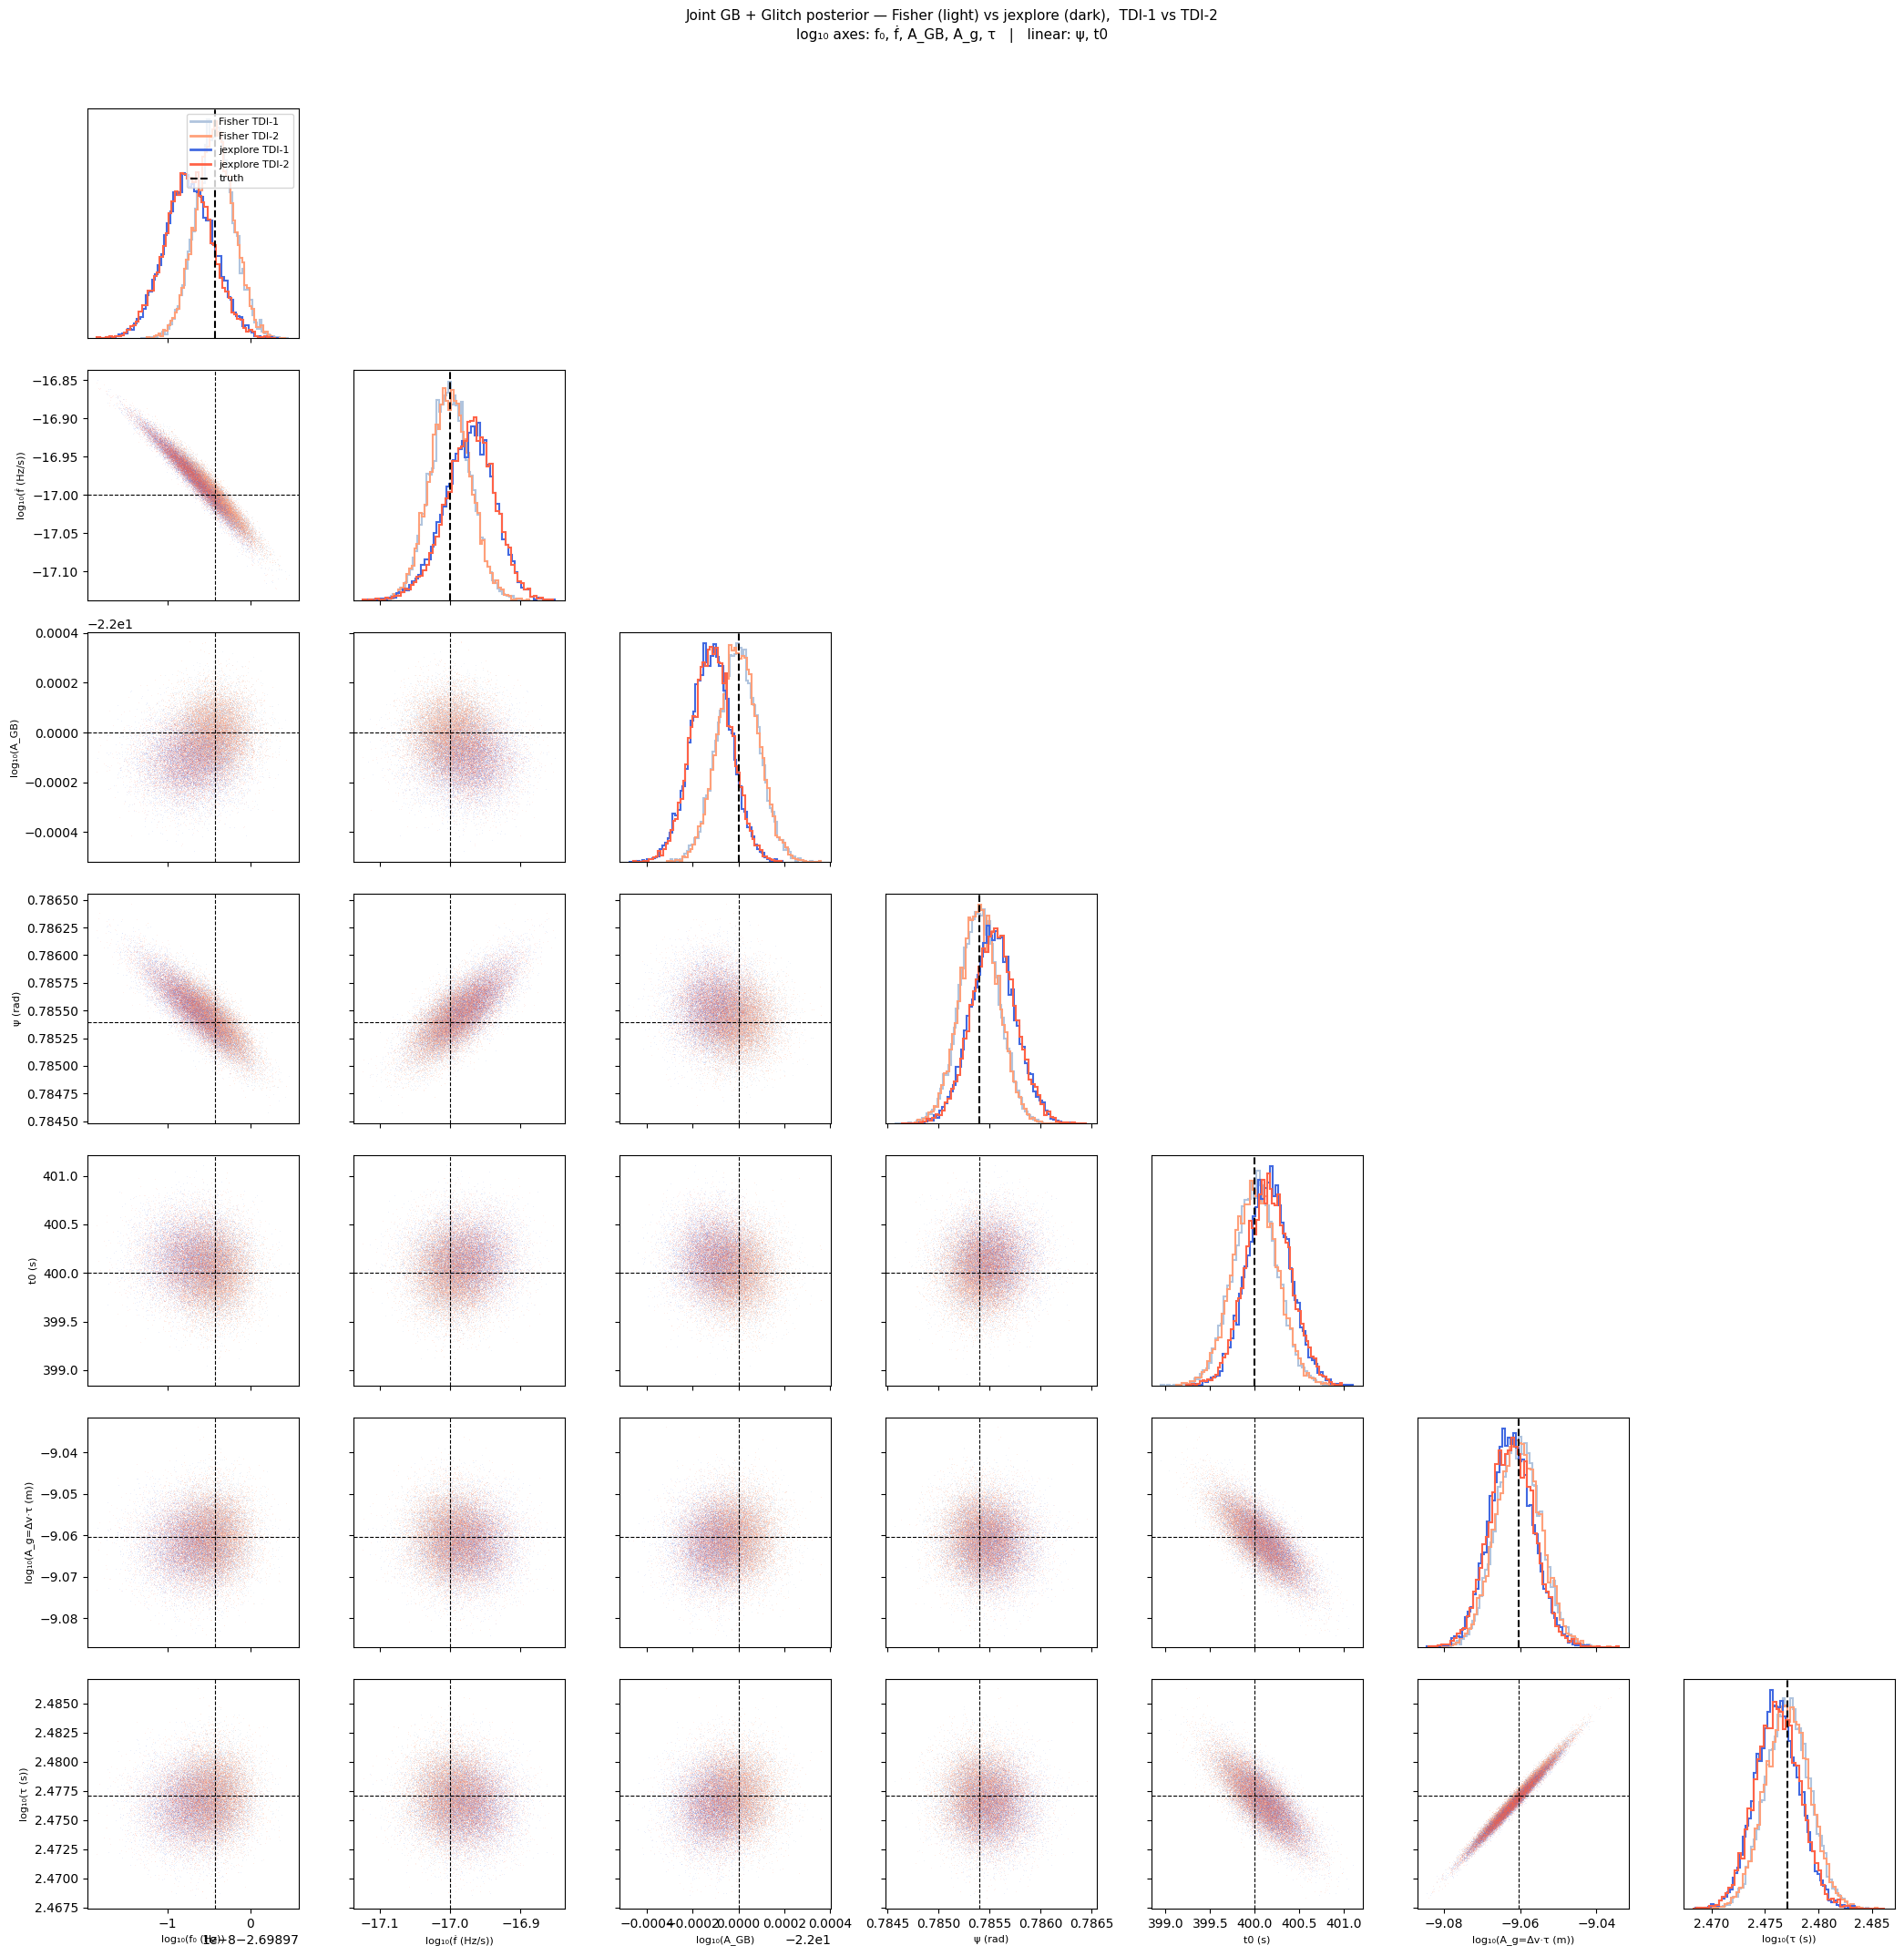

In [16]:
def corner_plot(samples_list, labels_list, colors, scatter_alphas,
                param_names, truths, log_axes=None):
    """Lower-triangle corner plot for an arbitrary number of sample sets."""
    n      = samples_list[0].shape[1]
    log_ax = set(log_axes or [])

    def _v(s, i): return jnp.log10(jnp.abs(s[:, i])) if i in log_ax else s[:, i]
    def _t(i):    return jnp.log10(abs(truths[i]))    if i in log_ax else truths[i]
    def _l(i):    return f'log₁₀({param_names[i]})' if i in log_ax else param_names[i]

    fig, axes = plt.subplots(n, n, figsize=(3*n, 3*n))
    fig.subplots_adjust(hspace=0.05, wspace=0.05)

    for row in range(n):
        for col in range(n):
            ax = axes[row, col]
            if col > row:
                ax.set_visible(False); continue
            if col == row:
                for s, lbl, clr in zip(samples_list, labels_list, colors):
                    ax.hist(_v(s, col), bins=60, density=True,
                            histtype='step', color=clr, lw=1.5, label=lbl)
                ax.axvline(_t(col), color='k', lw=1.5, ls='--')
                ax.set_yticks([])
            else:
                for s, _, clr, al in zip(samples_list, labels_list, colors, scatter_alphas):
                    ax.plot(_v(s, col), _v(s, row), ',', color=clr, alpha=al, ms=1)
                ax.axvline(_t(col), color='k', lw=0.8, ls='--')
                ax.axhline(_t(row), color='k', lw=0.8, ls='--')
            if row == n - 1:
                ax.set_xlabel(_l(col), fontsize=8)
            else:
                ax.set_xticklabels([])
            if col == 0 and row > 0:
                ax.set_ylabel(_l(row), fontsize=8)
            else:
                ax.set_yticklabels([])

    handles  = [plt.Line2D([0], [0], color=c, lw=2, label=l)
                for l, c in zip(labels_list, colors)]
    handles += [plt.Line2D([0], [0], color='k', lw=1.5, ls='--', label='truth')]
    axes[0, 0].legend(handles=handles, fontsize=8, loc='upper right')
    return fig


# Thin to ≈10 000 points per set for plotting speed
THIN   = max(1, chain1.shape[0]  // 10_000)
THIN_F = max(1, phys_f1.shape[0] // 10_000)

s1  = phys1[::THIN]
s2  = phys2[::THIN]
sf1 = phys_f1[::THIN_F]
sf2 = phys_f2[::THIN_F]

fig = corner_plot(
    [sf1,             sf2,             s1,               s2],
    ['Fisher TDI-1',  'Fisher TDI-2',  'jexplore TDI-1', 'jexplore TDI-2'],
    ['lightsteelblue','lightsalmon',   'royalblue',       'tomato'],
    [0.20,             0.20,            0.10,              0.10],   # 2-D scatter alpha
    param_names,
    truth_phys,
    log_axes={0, 1, 2, 5, 6}
)
fig.suptitle(
    'Joint GB + Glitch posterior — Fisher (light) vs jexplore (dark),  TDI-1 vs TDI-2\n'
    'log₁₀ axes: f₀, ḟ, A_GB, A_g, τ   |   linear: ψ, t0',
    y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

## 10. Whitened residual check

Posterior-median model subtracted from data in the GB window.  
Should be white noise (flat at 1) everywhere.

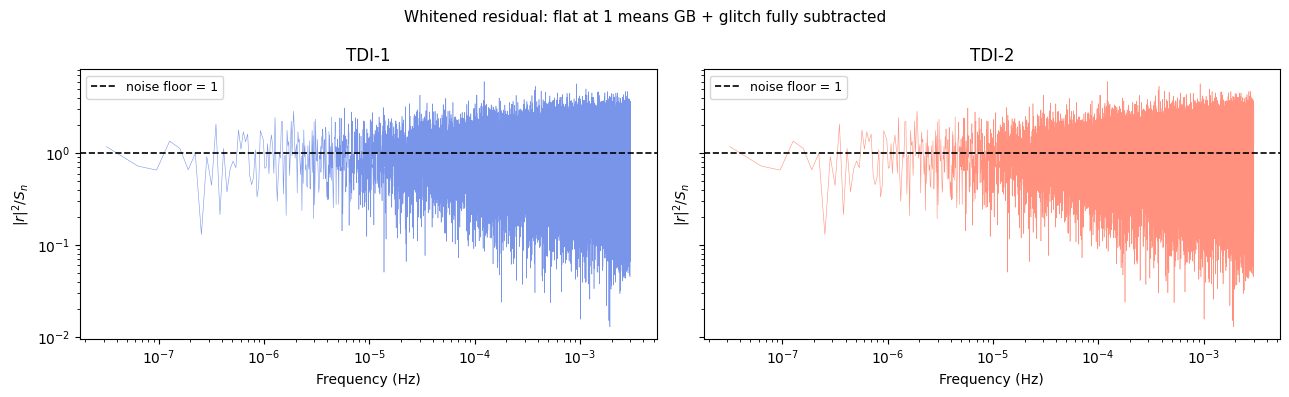

In [17]:
def posterior_model(chain, tdi):
    theta_med = jnp.median(chain, axis=0)
    gb8, g3   = to_physical(theta_med)

    # GB signal on full fine grid
    segs = jgb_model.get_tdi(gb8[None], tdi_generation=1.5, tdi_combination='AET')
    h_gb_seg = jnp.stack(segs, axis=0).astype(jnp.complex128)[:, 0, :].T  # (N_GB, 3)
    k_min_med = int(jgb_model.get_kmin(gb8[0:1])[0])
    h_gb_full = jnp.zeros((n_fine, 3), dtype=jnp.complex128)
    h_gb_full = h_gb_full.at[k_min_med + jnp.arange(N_GB)].set(h_gb_seg)

    if tdi == 2:
        h_gb_full = (-TFX1[:, None] * h_gb_full).at[0].set(0+0j)

    # Glitch signal on full fine grid
    h_g_full = glitch_h_tdi1(g3, f_safe) if tdi == 1 else glitch_h_tdi2(g3, f_safe)

    return (h_gb_full + h_g_full).at[0].set(0+0j)

h_med1 = posterior_model(chain1, tdi=1)
h_med2 = posterior_model(chain2, tdi=2)

res1 = data_tdi1 - h_med1
res2 = data_tdi2 - h_med2

f_plot = freq_fine[1:]
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, res, psd, title, clr in zip(
        axes, [res1, res2], [psd1_fine, psd2_fine],
        ['TDI-1', 'TDI-2'], ['royalblue', 'tomato']):
    wh = jnp.mean(jnp.abs(res[1:])**2 / psd[1:], axis=1)
    ax.loglog(f_plot, wh, color=clr, lw=0.4, alpha=0.7)
    ax.axhline(1.0, color='k', ls='--', lw=1.2, label='noise floor = 1')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel(r'$|r|^2 / S_n$')
    ax.set_title(title)
    ax.legend(fontsize=9)
plt.suptitle('Whitened residual: flat at 1 means GB + glitch fully subtracted', fontsize=11)
plt.tight_layout()
plt.show()

## 11. Time–frequency view of the glitch and the GB (WDM transform)

The signals are stored as analytic Fourier transforms `H(f)` of shape `(n_fine, 3)`; we map
channel A back to the time domain (`h(t) ≈ irfft(H)/Δt`) and then take the **Wilson–Daubechies–Meyer
(WDM) wavelet transform** from [`pywavelet/wdm_transform`](https://github.com/pywavelet/wdm_transform).

**Why WDM instead of an STFT.** A naïve year-long Hann-windowed spectrogram makes the glitch look
monochromatic: the burst (`~99 %` of its energy within ~10 samples of `t0 = 400 s`) collapses into a
single time column and is dropped where the long taper ≈ 0, leaving only the low-frequency sinc
ringing of the band-limited burst — which *is* constant in time — to dominate the image. The WDM
transform replaces that ad-hoc window by an **orthonormal, exactly invertible** tiling of the
time–frequency plane into `Nt × (Nf+1)` cells.

**One knob, set per signal.** A WDM grid still trades time against frequency resolution
(`Δt = Nf·Δt_sample`, `Δf = nyquist/Nf`) — the WDM analogue of a short vs long STFT window — so we use
two grids, just as the old code used two window lengths:
- **glitch** → coarse-frequency / **fine-time** grid (`Nf = 32`, `Δt ≈ 5333 s`, x-axis in **seconds** to
  match the time-domain panel). Very small `Nf` makes `Nt` huge and the transform runs out of memory, so
  `Δt ≈ 1.5 h` is the finest practical bin here — still wider than the few-sample burst, which therefore
  lands entirely in the **first time column**.
- **GB** → **fine-frequency** / coarse-time grid (`Nf = 256`, `Δf ≈ 12 µHz`, x-axis in days over the year).

**Result.** The **glitch is compact in time and broad in frequency** (all its power in the first time
bin, spread across every channel — a burst), while the **GB is a narrow 2 mHz line across all time**
(one frequency channel, every time bin). The time-domain panels make the contrast explicit.

Glitch: 99% of time-domain energy within t < 1667 s  (t0 = 400 s, τ = 300 s ≈ 1.8 samples)
Glitch WDM: Δt = 5333 s,  Δf = 0.094 mHz  (33 channels)
GB     WDM: Δt = 0.494 d,  Δf = 11.72 µHz  (257 channels)


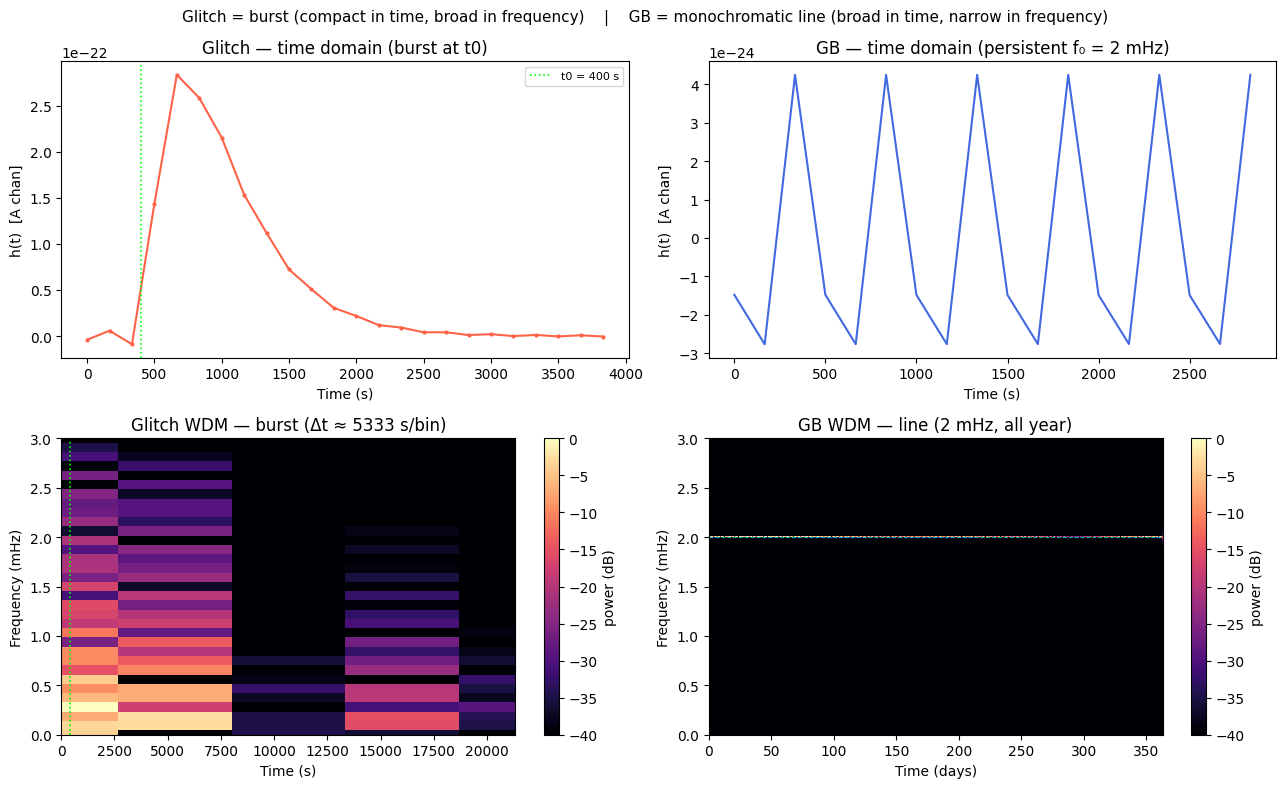

In [19]:
# ── Time/frequency: glitch (burst) vs GB (line) via the WDM transform ─────────
# Wilson–Daubechies–Meyer wavelet transform: https://github.com/pywavelet/wdm_transform
from wdm_transform import TimeSeries, WDM
from wdm_transform.backends import get_backend

WDM_BACKEND = get_backend('jax')   # keep everything on the JAX/x64 backend

def to_time(H_fd, chan=0):
    """Frequency-domain (n_fine, 3) -> real time series for one AET channel."""
    return jnp.fft.irfft(H_fd[:, chan], n=n_samples) / SAMPLING_STEP_s

# A WDM grid with NF frequency channels tiles the (0 … Nyquist = 3 mHz) band into
# NT × (NF+1) cells with  Δt = NF·Δt_sample  and  Δf = nyquist/NF.  Trading time vs
# frequency resolution is the WDM analogue of choosing a short vs long STFT window:
#   • glitch (burst)  -> few channels, FINE TIME  (NF_GLITCH, Δt ≈ 1.5 h/bin)
#   • GB    (line)    -> many channels, FINE FREQ (NF_GB_WDM, Δf ≈ 12 µHz)
# Very small NF blows nt up (the transform OOMs), so ~1.5 h is the finest practical
# time bin here — still wider than the ~few-sample burst, which therefore lands
# entirely in the first time column (compact in time, broad in frequency).
NF_GLITCH = 32     # coarse frequency / fine time  -> Δt ≈ 5333 s
NF_GB_WDM = 256    # fine frequency / coarse time  -> Δf ≈ 11.7 µHz

def wdm_grid(x, nf):
    """WDM coefficients of a real series, trimmed to a length divisible by nt (even)."""
    nt = (n_samples // nf) & ~1
    ts = TimeSeries(x[:nt * nf], dt=SAMPLING_STEP_s, backend=WDM_BACKEND)
    return WDM.from_time_series(ts, nt=nt)

x_glitch = to_time(h_glitch_tdi1)
x_gb     = to_time(h_gb_tdi1)
t_full   = jnp.arange(n_samples) * SAMPLING_STEP_s

# Sanity check: the glitch really is compact in time around t0.
p = jnp.abs(x_glitch) ** 2
e99 = float(t_full[int(jnp.searchsorted(jnp.cumsum(p) / jnp.sum(p), 0.99))])
print(f'Glitch: 99% of time-domain energy within t < {e99:.0f} s  '
      f'(t0 = {T0_TRUE:.0f} s, τ = {TAU_TRUE:.0f} s ≈ {TAU_TRUE/SAMPLING_STEP_s:.1f} samples)')

w_glitch = wdm_grid(x_glitch, NF_GLITCH)
w_gb     = wdm_grid(x_gb,     NF_GB_WDM)
print(f'Glitch WDM: Δt = {w_glitch.delta_t:.0f} s,  Δf = {w_glitch.delta_f*1e3:.3f} mHz  '
      f'({w_glitch.nf + 1} channels)')
print(f'GB     WDM: Δt = {w_gb.delta_t/86400:.3f} d,  Δf = {w_gb.delta_f*1e6:.2f} µHz  '
      f'({w_gb.nf + 1} channels)')

def plot_wdm(ax, w, title, tscale=86400.0, tlabel='Time (days)'):
    """dB image of the WDM coefficient power over (time, frequency [mHz])."""
    z   = jnp.abs(w.coeffs[0]).T                          # (nf+1, nt)
    zdb = 10.0 * jnp.log10(z**2 / jnp.max(z**2) + 1e-12)
    pcm = ax.pcolormesh(w.time_grid / tscale, w.freq_grid * 1e3, zdb,
                        shading='auto', cmap='magma', vmin=-40, vmax=0)
    ax.set(title=title, xlabel=tlabel, ylabel='Frequency (mHz)', ylim=(0, 3))
    fig.colorbar(pcm, ax=ax, label='power (dB)')
    return pcm

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# (a) glitch time series — the burst at t0
ax = axes[0, 0]
m = t_full < 4000.0
ax.plot(t_full[m], x_glitch[m], color='tomato', marker='.', ms=4)
ax.axvline(T0_TRUE, color='lime', ls=':', lw=1.2, label=f't0 = {T0_TRUE:.0f} s')
ax.set(title='Glitch — time domain (burst at t0)', xlabel='Time (s)', ylabel='h(t)  [A chan]')
ax.legend(fontsize=8)

# (b) GB time series — persistent 2 mHz oscillation
ax = axes[0, 1]
m = t_full < 3000.0
ax.plot(t_full[m], x_gb[m], color='royalblue')
ax.set(title='GB — time domain (persistent f₀ = 2 mHz)', xlabel='Time (s)', ylabel='h(t)  [A chan]')

# (c) glitch WDM — fine-time grid, x-axis in SECONDS to match panel (a):
#     all the energy sits in the first time bin, spread across every channel (burst).
ax = axes[1, 0]
plot_wdm(ax, w_glitch, f'Glitch WDM — burst (Δt ≈ {w_glitch.delta_t:.0f} s/bin)',
         tscale=1.0, tlabel='Time (s)')
ax.axvline(T0_TRUE, color='lime', ls=':', lw=1.2)
ax.set_xlim(0, 4 * float(w_glitch.delta_t))     # first ~4 WDM time bins

# (d) GB WDM — fine-frequency grid: narrow 2 mHz line across the whole year
ax = axes[1, 1]
plot_wdm(ax, w_gb, 'GB WDM — line (2 mHz, all year)', tscale=86400.0, tlabel='Time (days)')
ax.axhline(F0_TRUE * 1e3, color='cyan', ls='--', lw=0.8, alpha=0.7)

plt.suptitle('Glitch = burst (compact in time, broad in frequency)    |    '
             'GB = monochromatic line (broad in time, narrow in frequency)', fontsize=11)
plt.tight_layout()
plt.show()